# Исследование поведения слушателей Яндекс Музыки

Сервисы потоковой музыки живут за счёт того, насколько хорошо они понимают своих слушателей. Если рекомендация попадает в настроение — пользователь дослушивает трек до конца, ставит лайк и возвращается завтра. Если промахивается — переключает и постепенно теряет доверие к сервису.

В этом исследовании мы возьмём открытый датасет Yambda от Яндекс Музыки и попробуем понять, как пользователи на самом деле взаимодействуют с музыкой: что они дослушивают, что бросают, в чём разница между "найденным самостоятельно" треком и тем, что предложил алгоритм. И есть ли у сервиса небольшая группа "меломанов", которая слушает в разы больше остальных.

## О данных

Yambda-50M — открытая выборка из ~47 млн событий прослушивания, опубликованная Яндексом на Hugging Face в мае 2025 года. Это подмножество полного датасета на 5 миллиардов событий — 10 000 случайных пользователей за 10 месяцев наблюдений.

В файле `listens.parquet` шесть колонок:

| Колонка | Тип | Описание |
|---|---|---|
| `uid` | uint32 | ID пользователя |
| `timestamp` | uint32 | Временная метка события (в минутах от начала периода наблюдений) |
| `item_id` | uint32 | ID трека |
| `is_organic` | uint8 | 1 — пользователь сам нашёл трек, 0 — алгоритм рекомендации |
| `played_ratio_pct` | uint16 | Какую долю трека прослушали, в процентах |
| `track_length_seconds` | uint32 | Длина трека в секундах |

## Гипотезы

Прежде чем смотреть на данные, сформулируем три предположения, которые будем проверять.

**Гипотеза 1.** Треки, которые пользователь нашёл сам, дослушиваются до конца чаще, чем те, что предложил алгоритм. Логика простая: когда человек сам ищет конкретную песню, он уже знает, что хочет её услышать. Рекомендация — это всегда лотерея.

**Гипотеза 2.** Короткие треки дослушиваются чаще длинных. Чем длиннее песня, тем выше шанс, что у слушателя закончится терпение, поездка в метро или рабочая задача.

**Гипотеза 3.** В сервисе есть небольшая группа пользователей-"меломанов", которые генерируют непропорционально большую долю всех прослушиваний. Это важно для бизнеса: понимая, кто эти люди, можно делать продукт лучше под них.

Кроме гипотез, проведём общее исследование данных: посмотрим на распределения, найдём аномалии, изучим разницу между типами слушателей.

## План исследования

1. Обзор данных - первый взгляд, размеры, типы, пропуски
2. Предобработка — аномалии, новые признаки
3. Исследовательский анализ — распределения ключевых метрик
4. Проверка гипотезы 1: органика vs рекомендации
5. Проверка гипотезы 2: длина трека и дослушиваемость
6. Проверка гипотезы 3: распределение активности пользователей
7. Сегментация пользователей
8. Общие выводы

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:.2f}'.format)

In [4]:
df = pd.read_parquet('../dataset/listens.parquet')
print(f'Строк: {len(df):,}')
print(f'Столбцов: {df.shape[1]}')
df.head(10)

Строк: 46,467,212
Столбцов: 6


,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds
0,100,39420,8326270,0,100,170
1,100,39420,1441281,0,100,105
2,100,39625,286361,0,100,185
3,100,40110,732449,0,100,240
4,100,40360,3397170,0,46,130
5,100,40380,7849270,0,100,205
6,100,40640,1449307,0,100,205
7,100,40785,6887232,0,100,145
8,100,40885,2996197,0,100,95
9,100,41130,6474571,0,100,245


In [5]:
df.dtypes

uid                     uint32
timestamp               uint32
item_id                 uint32
is_organic               uint8
played_ratio_pct        uint16
track_length_seconds    uint32
dtype: object

In [6]:
df.describe()

,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds
count,46467212.00,46467212.00,46467212.00,46467212.00,46467212.00,46467212.00
mean,498499.04,14448380.92,4713863.83,0.52,64.76,207.41
std,287300.10,7463941.69,2701184.22,0.50,44.09,89.21
min,100.00,0.00,22.00,0.00,0.00,5.00
25%,249400.00,8207915.00,2396488.00,0.00,7.00,165.00
50%,494200.00,15089450.00,4715228.00,1.00,100.00,200.00
75%,744600.00,21057150.00,7050175.00,1.00,100.00,230.00
max,1000000.00,26000000.00,9390623.00,1.00,159.00,2495.00


In [7]:
df.nunique()

uid                        9238
timestamp               5047118
item_id                  877168
is_organic                    2
played_ratio_pct            160
track_length_seconds        499
dtype: int64

In [8]:
print(df['is_organic'].value_counts(normalize=True))

is_organic
1   0.52
0   0.48
Name: proportion, dtype: float64


В нашем датасете находится почти 50 миллионов строк и 6 столбцов. Уникальных пользователей 9238, уникальных треков 877168.
Так же можем заметить, что соотношение органических треков, и тех, что предложил алгоритм почти равно, 51.6% на 48.4%
Можно заметить аномалию в прослушивании трека - максимальное значен 159 (предположительно, пользователь слушал трек на повторе)

Средняя длина трека по медиане примерно 3 минуты (207 секунд), минимальная 5 секунд(очень короткий трек), а максимальная - около 41 минуты(2495 секунд)

## 2. Предобработка данных

**Поиск пропусков**

In [22]:
df.isna().sum()

uid                     0
timestamp               0
item_id                 0
is_organic              0
played_ratio_pct        0
track_length_seconds    0
is_completed            0
track_length_minutes    0
track_length_cat        0
dtype: int64

In [10]:
total_duplicates = df.duplicated().sum()
print(total_duplicates)

225625


In [11]:
df = df.drop_duplicates()
df = df.reset_index(drop=True)
print(df.shape)

(46241587, 6)


**Теперь посчитаем сколько треков имеют аномельное значение >100**

In [12]:
print(f'Строк с played_ratio_pct > 100: {(df["played_ratio_pct"] > 100).sum():,}')

Строк с played_ratio_pct > 100: 215,571


**Теперь заменим все значения  >100 на 100**

In [13]:
df['played_ratio_pct'] = df['played_ratio_pct'].clip(upper=100)

**Теперь пример за дослушанный трек 80% от прослушивания, который будет равен 1, иначе ставим 0**

In [14]:
df['is_completed'] = (df['played_ratio_pct'] >= 80).astype(int)

**Добавим новый столбец track_length_minutes**

В нем переведем секунды в минуты, чтобы картина данных была более ясной

In [21]:
df['track_length_minutes'] = df['track_length_seconds'] /60

df.head()

,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds,is_completed,track_length_minutes,track_length_cat
0,100,39420,8326270,0,100,170,1,2.83,средний (2-3.5 мин)
1,100,39420,1441281,0,100,105,1,1.75,короткий (<2 мин)
2,100,39625,286361,0,100,185,1,3.08,средний (2-3.5 мин)
3,100,40110,732449,0,100,240,1,4.00,длинный (3.5-5 мин)
4,100,40360,3397170,0,46,130,0,2.17,средний (2-3.5 мин)


**Определяем длину трека, разбив по категориям**

In [20]:
df['track_length_cat'] = pd.cut(
    df['track_length_seconds'],
    bins=[0, 120, 210, 300, 99999],
    labels=['короткий (<2 мин)', 'средний (2-3.5 мин)', 'длинный (3.5-5 мин)', 'очень длинный (>5 мин)']
)

df.head()

,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds,is_completed,track_length_minutes,track_length_cat
0,100,39420,8326270,0,100,170,1,2.83,средний (2-3.5 мин)
1,100,39420,1441281,0,100,105,1,1.75,короткий (<2 мин)
2,100,39625,286361,0,100,185,1,3.08,средний (2-3.5 мин)
3,100,40110,732449,0,100,240,1,4.00,длинный (3.5-5 мин)
4,100,40360,3397170,0,46,130,0,2.17,средний (2-3.5 мин)


Пропуски в датасете обнаружены не были, а дубликатов строк было уже найдено более 200 000, поэтому мы их удалили.
Далее избавились от аномалий, где прослушиваемость трека была  >100% и заменили на 100%

Были созданы 2 новых признака: длина трека и прослушал пользователь трек(1) или нет(0), за 1 принимаем >=80%


## 3. Исследовательский анализ (EDA)

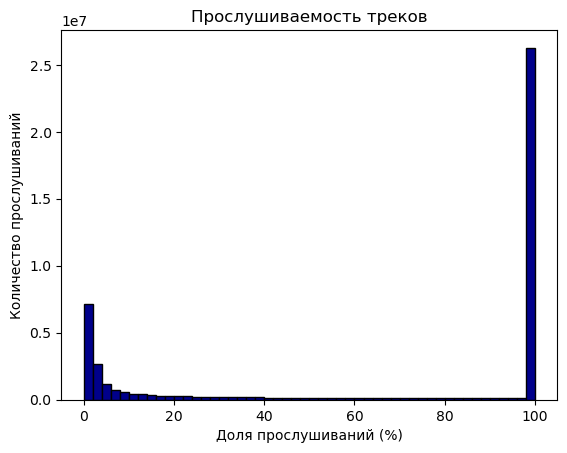

In [36]:
plt.hist(df['played_ratio_pct'], bins=50, color='darkblue', edgecolor='black')

plt.title('Прослушиваемость треков')
plt.xlabel('Доля прослушиваний (%)')
plt.ylabel('Количество прослушиваний')

plt.show()

In [37]:
print(df['is_completed'].value_counts(normalize=True))

is_completed
1   0.59
0   0.41
Name: proportion, dtype: float64
